In [7]:
import pandas as pd
import numpy as np

In [8]:
free_df = pd.read_csv('freedom_index.csv')
free_df.head()

,Year,Countries,Economic Freedom Index
0,2015,Albania,7.64
1,2015,Algeria,4.68
2,2015,Angola,5.25
3,2015,Argentina,4.95
4,2015,Armenia,7.43


In [9]:
health_df = pd.read_csv('total-healthcare-expenditure-gdp.csv')
health_df.head()

,Entity,Code,Year,Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)
0,Afghanistan,AFG,2002,9.44
1,Afghanistan,AFG,2003,8.94
2,Afghanistan,AFG,2004,9.81
3,Afghanistan,AFG,2005,9.95
4,Afghanistan,AFG,2006,10.62


# About Healthcare expenditure as a percent of GDP dataset:
The dataset contains information about current health expenditure (CHE) as a percentage of gross domestic product (GDP) for different countries. This metric is crucial as it indicates how much of a country's total economic output is dedicated to healthcare spending. Current health expenditure includes both public and private health expenditure and encompasses the provision of health services, family planning activities, nutrition activities, and emergency aid designated for health. However, it excludes water, sanitation, and hygiene services. The dataset comprises four main columns: Country names, their corresponding country codes, the year of measurement, and the actual percentage of GDP spent on healthcare. This standardized measure allows for meaningful comparisons of healthcare spending priorities across different economies, regardless of their absolute size or development status.

# Why we chose this dataset:
We selected the healthcare expenditure as a percentage of GDP dataset to explore its relationship with economic freedom for several compelling reasons. Firstly, this dataset provides a standardized way to compare healthcare spending across countries by expressing it as a percentage of GDP rather than absolute values, enabling fair comparisons regardless of the size of different economies. This normalization is crucial because it shows each country's prioritization of healthcare spending relative to their total economic output.

The dataset's measurement of current health expenditure (CHE) is comprehensive, encompassing both public and private healthcare spending, including essential components like health services provision, family planning activities, nutrition programs, and emergency health aid. This broad coverage helps us understand the total healthcare commitment of different economies rather than just government spending. However, it specifically excludes peripheral services like water, sanitation, and hygiene, ensuring we analyze pure healthcare expenditure.

Moreover, healthcare spending as a percentage of GDP is a critical indicator of a nation's healthcare system priorities and efficiency. By analyzing this against economic freedom scores, we can investigate whether countries with greater economic liberty tend to allocate their resources differently in healthcare. This could reveal important patterns about how economic policies might influence healthcare spending decisions. For instance, we can explore whether more economically free nations tend to spend a higher or lower proportion of their GDP on healthcare, and whether this correlates with better health outcomes.

Additionally, using this dataset allows us to examine potential relationships between economic systems and healthcare resource allocation. Since healthcare is a fundamental aspect of societal well-being, understanding how economic freedom might influence healthcare spending priorities could provide valuable insights for policymakers and researchers interested in the intersection of economic policies and public health outcomes.

In [10]:
health_df.rename(columns={'Entity':'Countries'},inplace=True)

In [11]:
health_df.head()

,Countries,Code,Year,Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)
0,Afghanistan,AFG,2002,9.44
1,Afghanistan,AFG,2003,8.94
2,Afghanistan,AFG,2004,9.81
3,Afghanistan,AFG,2005,9.95
4,Afghanistan,AFG,2006,10.62


In [12]:
merged_df = pd.merge(free_df,health_df,on=['Year','Countries'],how='inner')

In [13]:
merged_df.drop(columns='Code',inplace=True)

In [14]:
merged_df

,Year,Countries,Economic Freedom Index,Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)
0,2015,Albania,7.64,6.46
1,2015,Algeria,4.68,6.96
2,2015,Angola,5.25,2.61
3,2015,Argentina,4.95,10.23
4,2015,Armenia,7.43,10.12
...,...,...,...,...
985,2021,United States,8.07,17.36
986,2021,Uruguay,6.93,9.36
987,2021,Vietnam,6.24,4.59
988,2021,Zambia,5.63,6.62


In [15]:
l = []

In [16]:
for i in free_df[free_df['Year']==2022].sort_values(by='Economic Freedom Index',ascending=False).iloc[:10]['Countries']:
    l.append(i)

In [17]:
l

['Hong Kong',
 'Singapore',
 'Switzerland',
 'New Zealand',
 'United States',
 'Denmark',
 'Ireland',
 'Canada',
 'Luxembourg',
 'Australia']

In [18]:
l2=[]

In [19]:
l2 = list(free_df[free_df['Year']==2021].sort_values(by='Economic Freedom Index',ascending=False).iloc[:10]['Countries'])

In [20]:
free_df[free_df['Year']==2021].sort_values(by='Economic Freedom Index',ascending=False).iloc[:10]

,Year,Countries,Economic Freedom Index
1048,2021,Hong Kong,8.61
1115,2021,Singapore,8.53
1125,2021,Switzerland,8.47
1091,2021,New Zealand,8.43
1055,2021,Ireland,8.12
1024,2021,Denmark,8.10
1140,2021,United States,8.07
987,2021,Australia,8.00
1139,2021,United Kingdom,7.97
1010,2021,Canada,7.93


In [21]:
l2

['Hong Kong',
 'Singapore',
 'Switzerland',
 'New Zealand',
 'Ireland',
 'Denmark',
 'United States',
 'Australia',
 'United Kingdom',
 'Canada']

In [22]:
df2021 = merged_df[merged_df['Countries'].isin(l2)]

In [23]:
df2021

,Year,Countries,Economic Freedom Index,Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)
5,2015,Australia,8.24,10.18
25,2015,Canada,8.20,10.74
35,2015,Denmark,8.20,10.34
61,2015,Ireland,8.41,7.34
93,2015,New Zealand,8.83,9.28
...,...,...,...,...
943,2021,New Zealand,8.43,10.05
966,2021,Singapore,8.53,5.57
974,2021,Switzerland,8.47,11.80
984,2021,United Kingdom,7.97,12.36


In [24]:
df2021 = df2021[df2021['Year']==2021]
df2021.sort_values(by='Economic Freedom Index',ascending=False,inplace=True)
df2021

/var/folders/7q/f36dvxm10glfxdlgnvmb09dh0000gn/T/ipykernel_54818/3243869735.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2021.sort_values(by='Economic Freedom Index',ascending=False,inplace=True)


,Year,Countries,Economic Freedom Index,Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)
966,2021,Singapore,8.53,5.57
974,2021,Switzerland,8.47,11.80
943,2021,New Zealand,8.43,10.05
911,2021,Ireland,8.12,6.72
884,2021,Denmark,8.10,10.82
985,2021,United States,8.07,17.36
853,2021,Australia,8.00,10.54
984,2021,United Kingdom,7.97,12.36
873,2021,Canada,7.93,12.33


In [25]:
gdp_df = pd.read_csv('national-gdp-wb.csv')
gdp_df.head()

,Entity,Code,Year,"GDP, PPP (constant 2017 international $)"
0,Afghanistan,AFG,2021,6.080174e+10
1,Albania,ALB,2021,4.103912e+10
2,Algeria,DZA,2021,4.872450e+11
3,Angola,AGO,2021,2.039810e+11
4,Antigua and Barbuda,ATG,2021,1.911098e+09


# About GDP dataset:
The dataset contains GDP information measured in PPP (Purchasing Power Parity) using constant 2017 international dollars. It consists of four columns:

Entity: Names of different countries

Code: Unique country codes for identification

Year: The year of measurement

GDP, PPP: The GDP value adjusted for purchasing power parity, using 2017 as the base year for constant prices

PPP adjustment is important because it accounts for different price levels across countries. For example, $1 might buy different amounts of goods in different countries due to varying price levels. By using PPP, we get a more accurate comparison of actual purchasing power and living standards between countries. Additionally, using constant 2017 dollars means all values are adjusted for inflation to that year, making year-to-year comparisons more meaningful by removing the effect of price changes over time.

# Why we chose this dataset:

We selected the GDP (PPP) dataset to analyze whether a country's economic freedom has any relationship with its economic output and standard of living. This dataset is particularly valuable because it uses Purchasing Power Parity (PPP) adjustment in constant 2017 international dollars, which provides a more accurate basis for comparing economic output across countries. Unlike nominal GDP, PPP-adjusted figures account for differences in price levels between countries, giving us a clearer picture of real economic differences rather than those arising from price variations or exchange rates.

Moreover, since economic freedom is meant to promote economic growth and prosperity, examining its relationship with GDP (PPP) allows us to test this theoretical connection with actual data. Using constant 2017 dollars ensures that our analysis isn't distorted by inflation over time, making the comparisons more meaningful. This dataset helps us explore whether countries with higher economic freedom scores actually achieve higher levels of economic output when accounting for purchasing power differences, providing insights into the real-world impact of economic freedom policies on a country's economic performance.

In [26]:
merged_df2 = pd.merge(df2021,gdp_df,left_on='Countries',right_on='Entity',how='inner')
merged_df2

,Year_x,Countries,Economic Freedom Index,Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%),Entity,Code,Year_y,"GDP, PPP (constant 2017 international $)"
0,2021,Singapore,8.53,5.57,Singapore,SGP,2021,5.875730e+11
1,2021,Switzerland,8.47,11.80,Switzerland,CHE,2021,6.184130e+11
2,2021,New Zealand,8.43,10.05,New Zealand,NZL,2021,2.251160e+11
3,2021,Ireland,8.12,6.72,Ireland,IRL,2021,5.268310e+11
4,2021,Denmark,8.10,10.82,Denmark,DNK,2021,3.443930e+11
5,2021,United States,8.07,17.36,United States,USA,2021,2.112910e+13
6,2021,Australia,8.00,10.54,Australia,AUS,2021,1.274230e+12
7,2021,United Kingdom,7.97,12.36,United Kingdom,GBR,2021,3.054230e+12
8,2021,Canada,7.93,12.33,Canada,CAN,2021,1.848490e+12


In [27]:
merged_df2.rename(columns={'GDP, PPP (constant 2017 international $)':'GDP 2021','Year_x':'Year','Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)':'Health Expenditure percentage'},inplace=True)

In [28]:
merged_df2

,Year,Countries,Economic Freedom Index,Health Expenditure percentage,Entity,Code,Year_y,GDP 2021
0,2021,Singapore,8.53,5.57,Singapore,SGP,2021,5.875730e+11
1,2021,Switzerland,8.47,11.80,Switzerland,CHE,2021,6.184130e+11
2,2021,New Zealand,8.43,10.05,New Zealand,NZL,2021,2.251160e+11
3,2021,Ireland,8.12,6.72,Ireland,IRL,2021,5.268310e+11
4,2021,Denmark,8.10,10.82,Denmark,DNK,2021,3.443930e+11
5,2021,United States,8.07,17.36,United States,USA,2021,2.112910e+13
6,2021,Australia,8.00,10.54,Australia,AUS,2021,1.274230e+12
7,2021,United Kingdom,7.97,12.36,United Kingdom,GBR,2021,3.054230e+12
8,2021,Canada,7.93,12.33,Canada,CAN,2021,1.848490e+12


In [29]:
merged_df2.drop(columns=['Code','Entity','Year_y'],inplace=True)

In [30]:
merged_df2

,Year,Countries,Economic Freedom Index,Health Expenditure percentage,GDP 2021
0,2021,Singapore,8.53,5.57,5.875730e+11
1,2021,Switzerland,8.47,11.80,6.184130e+11
2,2021,New Zealand,8.43,10.05,2.251160e+11
3,2021,Ireland,8.12,6.72,5.268310e+11
4,2021,Denmark,8.10,10.82,3.443930e+11
5,2021,United States,8.07,17.36,2.112910e+13
6,2021,Australia,8.00,10.54,1.274230e+12
7,2021,United Kingdom,7.97,12.36,3.054230e+12
8,2021,Canada,7.93,12.33,1.848490e+12


In [31]:
pop_df = pd.read_csv('population.csv')
pop_df

,Entity,Code,Year,Population (historical)
0,Afghanistan,AFG,2019,37856126
1,Afghanistan,AFG,2020,39068978
2,Afghanistan,AFG,2021,40000411
3,Afghanistan,AFG,2022,40578846
4,Afghanistan,AFG,2023,41454762
...,...,...,...,...
1295,Zimbabwe,ZWE,2019,15271377
1296,Zimbabwe,ZWE,2020,15526888
1297,Zimbabwe,ZWE,2021,15797220
1298,Zimbabwe,ZWE,2022,16069061


# About this dataset:

The dataset provides historical population statistics for different countries. It contains four columns: Entity (country names), Code (country identification codes), Year (time period of measurement), and Population (historical). The population figures represent the total number of people residing in each country for the given year. This demographic data is crucial for understanding the size and scale of different nations and can be used to derive per capita metrics that allow for more meaningful comparisons between countries of different sizes. Historical population data also helps track demographic changes and growth patterns over time, providing context for other socio-economic indicators.

# Why we chose this dataset:

We selected the population dataset primarily to calculate GDP per capita, which provides a more meaningful measure of economic output and standard of living than total GDP alone. By dividing a country's GDP by its population, we can understand the average economic output per person, allowing for fairer comparisons between countries of different sizes. For instance, while a large country might have a higher total GDP, its GDP per capita could be lower than a smaller country, indicating a lower average standard of living. This population dataset, combined with our GDP (PPP) data, enables us to examine whether countries with higher economic freedom tend to have higher GDP per capita, which is a better indicator of individual economic well-being than aggregate GDP. Additionally, population data helps us understand the scale of each country's economy and provides context for other metrics in our analysis.

In [32]:
pop_df.rename(columns={'Entity':'Countries','Population (historical)':'Population'},inplace=True)
pop_df

,Countries,Code,Year,Population
0,Afghanistan,AFG,2019,37856126
1,Afghanistan,AFG,2020,39068978
2,Afghanistan,AFG,2021,40000411
3,Afghanistan,AFG,2022,40578846
4,Afghanistan,AFG,2023,41454762
...,...,...,...,...
1295,Zimbabwe,ZWE,2019,15271377
1296,Zimbabwe,ZWE,2020,15526888
1297,Zimbabwe,ZWE,2021,15797220
1298,Zimbabwe,ZWE,2022,16069061


In [33]:
merged_df3 = pd.merge(merged_df2,pop_df,on=['Year','Countries'],how='inner')

In [34]:
merged_df3 = merged_df3.drop(columns='Code')
merged_df3

,Year,Countries,Economic Freedom Index,Health Expenditure percentage,GDP 2021,Population
0,2021,Singapore,8.53,5.57,5.875730e+11,5546292
1,2021,Switzerland,8.47,11.80,6.184130e+11,8707018
2,2021,New Zealand,8.43,10.05,2.251160e+11,5107696
3,2021,Ireland,8.12,6.72,5.268310e+11,5028430
4,2021,Denmark,8.10,10.82,3.443930e+11,5856773
5,2021,United States,8.07,17.36,2.112910e+13,340161441
6,2021,Australia,8.00,10.54,1.274230e+12,25956416
7,2021,United Kingdom,7.97,12.36,3.054230e+12,67668789
8,2021,Canada,7.93,12.33,1.848490e+12,38454058


In [35]:
merged_df3['GDP per capita'] = merged_df3['GDP 2021']/merged_df3['Population']

In [36]:
merged_df3['Health Expenditure in usd'] = merged_df3['Health Expenditure percentage']*merged_df3['GDP 2021']/100

In [37]:
merged_df3

,Year,Countries,Economic Freedom Index,Health Expenditure percentage,GDP 2021,Population,GDP per capita,Health Expenditure in usd
0,2021,Singapore,8.53,5.57,5.875730e+11,5546292,105939.788241,3.272782e+10
1,2021,Switzerland,8.47,11.80,6.184130e+11,8707018,71024.660797,7.297273e+10
2,2021,New Zealand,8.43,10.05,2.251160e+11,5107696,44073.883802,2.262416e+10
3,2021,Ireland,8.12,6.72,5.268310e+11,5028430,104770.475079,3.540304e+10
4,2021,Denmark,8.10,10.82,3.443930e+11,5856773,58802.518042,3.726332e+10
5,2021,United States,8.07,17.36,2.112910e+13,340161441,62114.917957,3.668012e+12
6,2021,Australia,8.00,10.54,1.274230e+12,25956416,49091.138006,1.343038e+11
7,2021,United Kingdom,7.97,12.36,3.054230e+12,67668789,45134.988303,3.775028e+11
8,2021,Canada,7.93,12.33,1.848490e+12,38454058,48070.089248,2.279188e+11


In [38]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [39]:
df= merged_df3

In [40]:
diet_df = pd.read_csv('share-healthy-diet-unaffordable.csv')
diet_df.to_csv('diet_df.csv')

In [41]:
diet_df

,Countries,Code,Year,Share of the population who cannot afford a healthy diet
0,Albania,ALB,2021,12.6
1,Algeria,DZA,2021,18.7
2,Angola,AGO,2021,71.7
3,Armenia,ARM,2021,54.1
4,Australia,AUS,2021,3.2
...,...,...,...,...
157,Uruguay,URY,2021,37.8
158,Uzbekistan,UZB,2021,15.7
159,Vietnam,VNM,2021,9.6
160,World,OWID_WRL,2021,36.4


# About the 'Share of the population who cannot afford a healthy diet' population:

The dataset measures food affordability across different countries by calculating the percentage of the population unable to afford a healthy diet. It consists of four columns: Countries (names of nations), Code (country identification codes), Year (time period of measurement), and Share of the population who cannot afford a healthy diet (expressed as a percentage). This metric is particularly important as it goes beyond basic food affordability to specifically measure access to nutritious food that meets dietary requirements. A healthy diet refers to food that provides not just adequate calories, but also essential nutrients needed for active and healthy living. The percentage represents the proportion of people in each country who cannot regularly access such a diet due to economic constraints, making it a crucial indicator of both food security and economic well-being of a population.

# Why we chose this dataset:

We selected the 'Share of the population who cannot afford a healthy diet' dataset to investigate whether economic freedom has any influence on people's ability to access nutritious food. This metric is particularly revealing because it doesn't just measure general food availability or hunger, but specifically focuses on the economic accessibility of a healthy diet. By analyzing this against economic freedom scores, we can explore whether countries with greater economic liberty are more successful at making healthy food affordable for their populations.

The choice of this dataset adds a crucial human dimension to our analysis. While metrics like GDP and healthcare expenditure tell us about the macro-economic picture, food affordability directly impacts people's daily lives and well-being. It helps us understand if economic freedom translates into tangible benefits for populations in terms of their ability to maintain a healthy diet. Additionally, this metric indirectly reflects income distribution and living standards, as it shows what percentage of the population faces economic barriers to proper nutrition, providing insights into whether economic freedom correlates with better food accessibility across all segments of society.

In [88]:
diet_df.columns

Index(['Countries', 'Code', 'Year',
       'Share of the population who cannot afford a healthy diet'],
      dtype='object')

In [89]:
diet_df.drop(columns='Code',inplace=True)

In [90]:
df

,Year,Countries,Economic Freedom Index,Health Expenditure percentage,GDP 2021,Population,GDP per capita,Health Expenditure in usd
0,2021,Singapore,8.53,5.57,5.875730e+11,5546292,105939.788241,3.272782e+10
1,2021,Switzerland,8.47,11.80,6.184130e+11,8707018,71024.660797,7.297273e+10
2,2021,New Zealand,8.43,10.05,2.251160e+11,5107696,44073.883802,2.262416e+10
3,2021,Ireland,8.12,6.72,5.268310e+11,5028430,104770.475079,3.540304e+10
4,2021,Denmark,8.10,10.82,3.443930e+11,5856773,58802.518042,3.726332e+10
5,2021,United States,8.07,17.36,2.112910e+13,340161441,62114.917957,3.668012e+12
6,2021,Australia,8.00,10.54,1.274230e+12,25956416,49091.138006,1.343038e+11
7,2021,United Kingdom,7.97,12.36,3.054230e+12,67668789,45134.988303,3.775028e+11
8,2021,Canada,7.93,12.33,1.848490e+12,38454058,48070.089248,2.279188e+11


In [91]:
df = pd.merge(df,diet_df,on=['Countries','Year'],how='inner')

In [93]:
df

,Year,Countries,Economic Freedom Index,Health Expenditure percentage,GDP 2021,Population,GDP per capita,Health Expenditure in usd,Share of the population who cannot afford a healthy diet
0,2021,Singapore,8.53,5.57,5.875730e+11,5546292,105939.788241,3.272782e+10,0.7
1,2021,Switzerland,8.47,11.80,6.184130e+11,8707018,71024.660797,7.297273e+10,1.2
2,2021,New Zealand,8.43,10.05,2.251160e+11,5107696,44073.883802,2.262416e+10,1.8
3,2021,Ireland,8.12,6.72,5.268310e+11,5028430,104770.475079,3.540304e+10,1.1
4,2021,Denmark,8.10,10.82,3.443930e+11,5856773,58802.518042,3.726332e+10,0.8
5,2021,United States,8.07,17.36,2.112910e+13,340161441,62114.917957,3.668012e+12,2.5
6,2021,Australia,8.00,10.54,1.274230e+12,25956416,49091.138006,1.343038e+11,3.2
7,2021,United Kingdom,7.97,12.36,3.054230e+12,67668789,45134.988303,3.775028e+11,3.0
8,2021,Canada,7.93,12.33,1.848490e+12,38454058,48070.089248,2.279188e+11,3.0


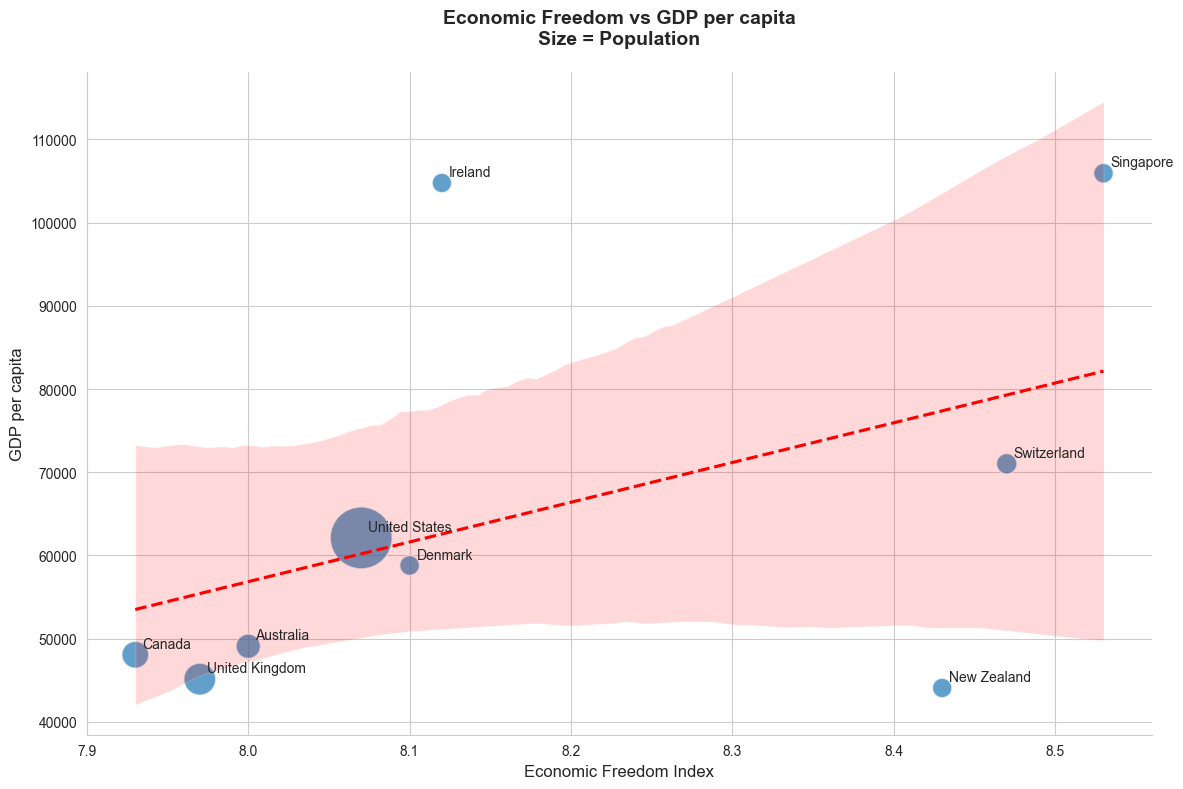

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
scatter = sns.scatterplot(data=df,
                         x='Economic Freedom Index',
                         y='GDP per capita',
                         size='Population',  
                         sizes=(200, 2000),
                         alpha=0.7,
                         legend=False)  # Remove legend

# Add country labels
for idx, row in df.iterrows():
    plt.annotate(row['Countries'], 
                (row['Economic Freedom Index'], row['GDP per capita']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=10)

# Customize the plot
plt.title('Economic Freedom vs GDP per capita\nSize = Population', 
         pad=20, 
         fontsize=14, 
         fontweight='bold')

plt.xlabel('Economic Freedom Index', fontsize=12)
plt.ylabel('GDP per capita (USD)', fontsize=12)

# Add trend line
sns.regplot(data=df,
            x='Economic Freedom Index',
            y='GDP per capita',
            scatter=False,
            color='red',
            line_kws={'linestyle': '--'})

# Adjust layout
plt.tight_layout()

# Remove top and right spines
sns.despine()

# Observation:

1. Overall Trend:


- The red dashed line shows a positive correlation between Economic Freedom Index and GDP per capita
- The pink shaded area represents the confidence interval, showing some uncertainty in this relationship
- Generally, countries with higher economic freedom tend to have higher GDP per capita


2. Country-Specific Observations:


- Singapore (EFI: 8.5) and Ireland (EFI: 8.1) stand notably above the trend line:

- - Singapore: Highest economic freedom and among highest GDP per capita (~105,000 USD)
- - Ireland: Despite lower economic freedom than Singapore, maintains high GDP per capita (~104,000 USD)


- Switzerland shows strong performance:

- - High economic freedom (8.47)
- - Relatively high GDP per capita (~71,000 USD)


- United States presents interesting case:

- - Large bubble size indicating large population
- - Moderate-high economic freedom (8.07)
- - GDP per capita around 62,000 USD


- New Zealand appears as an outlier:

- - High economic freedom (8.43)
- - Lower GDP per capita than might be expected (~44,000 USD)
- - Falls below the trend line




3. Population Insights (shown by bubble size):


- United States: Largest bubble, showing largest population
- Most other countries have smaller populations
- Interestingly, population size doesn't seem to have a clear relationship with either economic freedom or GDP per capita


4. Clustering Patterns:


- Lower EFI cluster (7.9-8.0):

- - Canada, UK, Australia
- - Similar GDP per capita levels (45,000-50,000 USD)


- Middle EFI (8.0-8.2):

- - US, Denmark
- - Higher GDP per capita than lower EFI cluster


- Higher EFI (8.4-8.5):

- - Singapore, Switzerland
- - Generally higher GDP per capita, except New Zealand




5. Implications:


- The positive trend suggests economic freedom might contribute to higher GDP per capita
- However, outliers like Ireland and New Zealand indicate other factors also play important roles
- Population size doesn't seem to be a limiting factor for either economic freedom or GDP per capita
- The relationship isn't perfectly linear, suggesting complex interactions between economic freedom and wealth generation

This visualization effectively demonstrates that while higher economic freedom generally correlates with higher GDP per capita, the relationship is nuanced and likely influenced by many other factors specific to each country's circumstances.

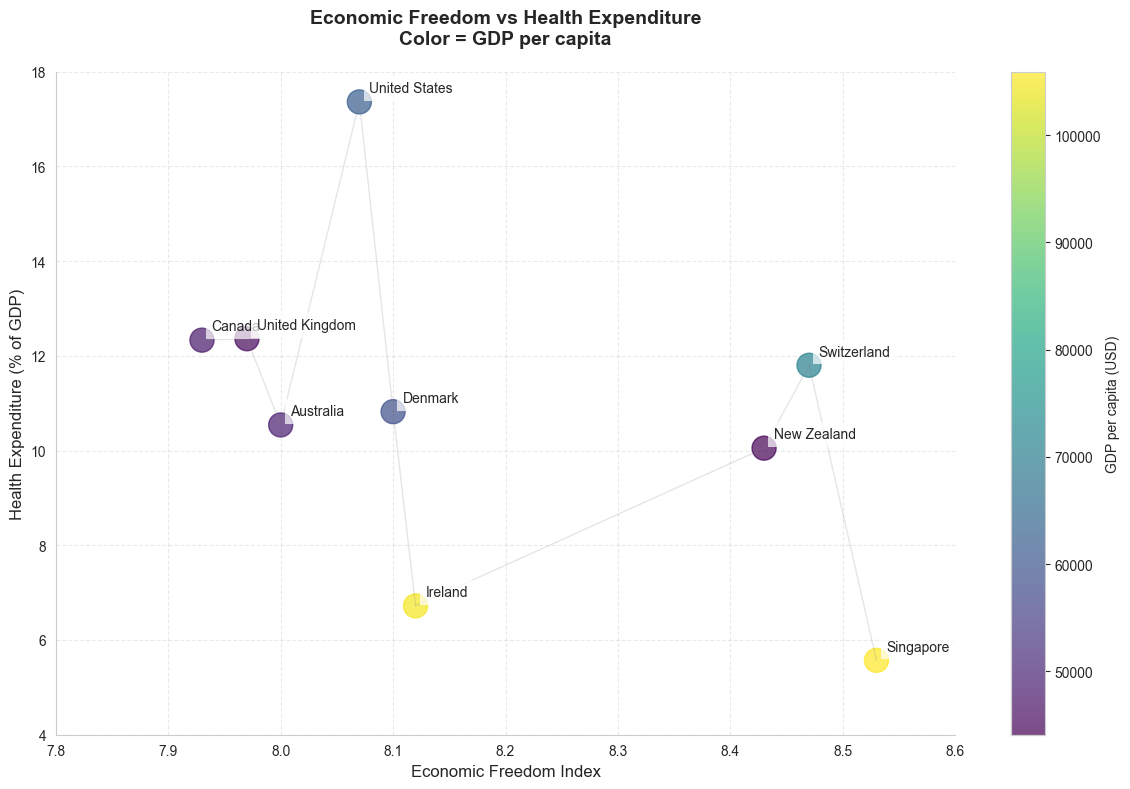

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sort by Economic Freedom Index
df_sorted = df.sort_values('Economic Freedom Index')

# Set style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# Create gradient color for lines based on GDP per capita
gdp_norm = (df_sorted['GDP per capita'] - df_sorted['GDP per capita'].min()) / \
           (df_sorted['GDP per capita'].max() - df_sorted['GDP per capita'].min())

# Create the connecting lines
for i in range(len(df_sorted)-1):
    plt.plot([df_sorted['Economic Freedom Index'].iloc[i], 
              df_sorted['Economic Freedom Index'].iloc[i+1]],
             [df_sorted['Health Expenditure percentage'].iloc[i], 
              df_sorted['Health Expenditure percentage'].iloc[i+1]],
             color='gray', alpha=0.2, linewidth=1)

# Create main scatter plot with custom colors
scatter = plt.scatter(df_sorted['Economic Freedom Index'],
                     df_sorted['Health Expenditure percentage'],
                     c=df_sorted['GDP per capita'],
                     s=300,
                     cmap='viridis',
                     alpha=0.7)

# Add country labels with white background for better readability
for idx, row in df_sorted.iterrows():
    plt.annotate(row['Countries'],
                (row['Economic Freedom Index'], row['Health Expenditure percentage']),
                xytext=(7, 7),
                textcoords='offset points',
                fontsize=10,
                bbox=dict(facecolor='white', 
                         edgecolor='none',
                         alpha=0.7))

# Customize plot
plt.title('Economic Freedom vs Health Expenditure\nColor = GDP per capita', 
         pad=20, 
         fontsize=14, 
         fontweight='bold')

plt.xlabel('Economic Freedom Index', fontsize=12)
plt.ylabel('Health Expenditure (% of GDP)', fontsize=12)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('GDP per capita (USD)', fontsize=10)

# Customize grid
plt.grid(True, linestyle='--', alpha=0.4)

# Set axis limits with some padding
plt.xlim(7.8, 8.6)
plt.ylim(4, 18)

# Adjust layout
plt.tight_layout()

# Remove top and right spines
sns.despine()

# Observations:


1. Overall Pattern:
- No clear linear relationship between Economic Freedom Index and health expenditure
- Wide variation in healthcare spending (5.57% to 17.36% of GDP)
- GDP per capita (shown by color gradient) adds interesting context to spending patterns

2. Notable Extremes:
- United States:
  * Moderate-high economic freedom (8.07)
  * Highest health expenditure (17.36% of GDP)
  * Stands as a significant outlier in healthcare spending

- Singapore:
  * Highest economic freedom (8.53)
  * Lowest health expenditure (5.57% of GDP)
  * High GDP per capita (shown by yellow color)

3. Clustering Patterns:
- Upper Cluster (11-12% spending):
  * Switzerland (11.80%)
  * United Kingdom (12.36%)
  * Canada (12.33%)
  * Similar spending despite different economic freedom scores

- Middle Cluster (10-11% spending):
  * Denmark (10.82%)
  * Australia (10.54%)
  * New Zealand (10.05%)

- Lower Cluster (5-7% spending):
  * Singapore (5.57%)
  * Ireland (6.72%)
  * Both have high GDP per capita (yellow coloring)

4. GDP per Capita Insights (shown by colors):
- Countries with highest GDP per capita (yellower dots):
  * Singapore
  * Ireland
  * Interestingly, both have lower healthcare spending
- Countries with lower GDP per capita (purple dots):
  * Generally spend higher percentages on healthcare
  * Example: UK, Canada, Australia

5. Implications:
- Economic freedom doesn't directly determine healthcare spending
- High economic freedom can coexist with both high and low healthcare spending
- Wealthy countries (high GDP per capita) don't necessarily spend higher percentages on healthcare
- Healthcare spending seems more influenced by policy choices and healthcare system structure than economic freedom alone

This visualization effectively shows that the relationship between economic freedom and healthcare spending is complex and likely influenced by various factors including policy choices, healthcare system efficiency, and overall economic development.

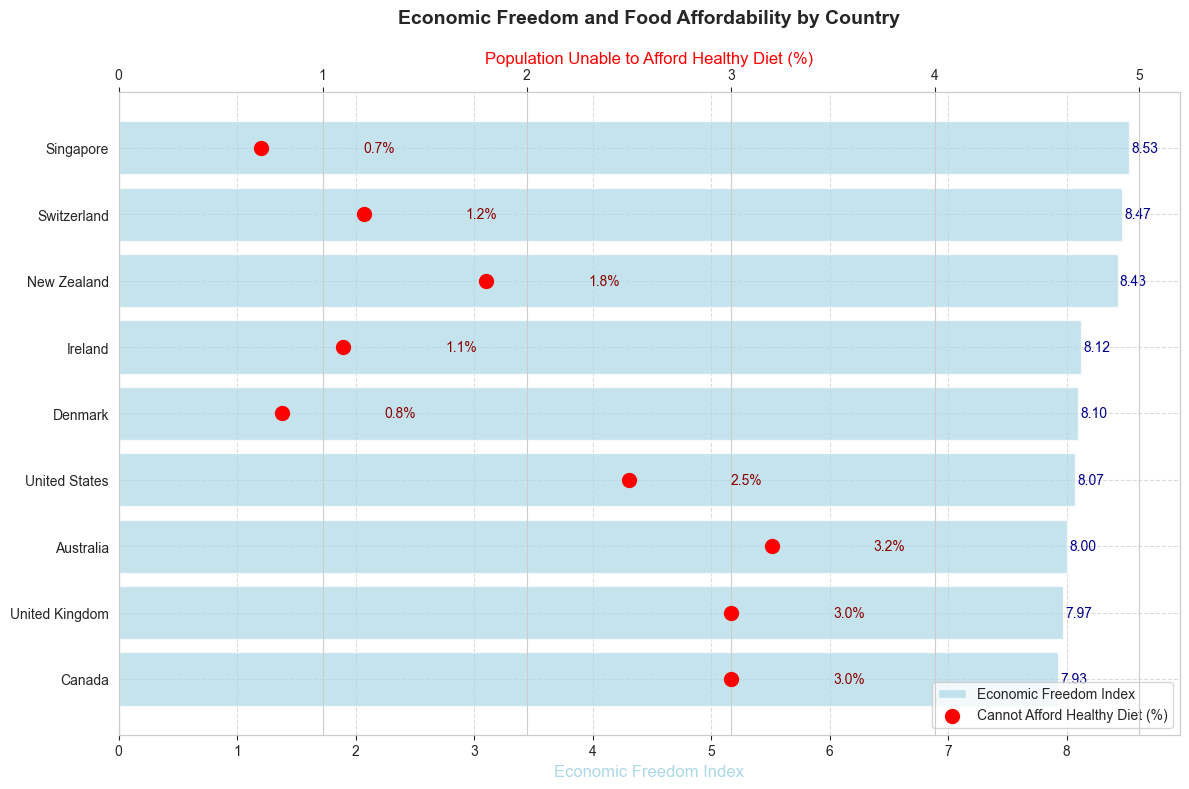

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Sort countries by Economic Freedom Index
df_sorted = df.sort_values('Economic Freedom Index', ascending=True)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))

# Create bars for Economic Freedom
bars = ax1.barh(df_sorted['Countries'], 
                df_sorted['Economic Freedom Index'],
                color='lightblue',
                alpha=0.7,
                label='Economic Freedom Index')

# Create second axis for inability to afford healthy diet
ax2 = ax1.twiny()
points = ax2.scatter(df_sorted['Share of the population who cannot afford a healthy diet'],
                    df_sorted['Countries'],
                    color='red',
                    s=100,
                    label='Cannot Afford Healthy Diet (%)')

# Customize plot
ax1.set_xlabel('Economic Freedom Index', color='lightblue', fontsize=12)
ax2.set_xlabel('Population Unable to Afford Healthy Diet (%)', color='red', fontsize=12)
plt.title('Economic Freedom and Food Affordability by Country', 
         pad=20, 
         fontsize=14, 
         fontweight='bold')

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             ha='left', va='center',
             color='darkblue',
             fontsize=10)

# Add value labels for scatter points - Moved further right
for i, value in enumerate(df_sorted['Share of the population who cannot afford a healthy diet']):
    ax2.text(value + 0.5, i,  # Increased the x-offset to move labels right
             f'{value:.1f}%',
             ha='left', va='center',
             color='darkred',
             fontsize=10)

# Customize axes
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Set x-axis limit for second axis to accommodate labels
max_affordability = df_sorted['Share of the population who cannot afford a healthy diet'].max()
ax2.set_xlim(0, max_affordability + 2)  # Added more space for labels

# Create combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
          loc='lower right',
          fontsize=10)

plt.tight_layout()

# Observation:


1. Overall Pattern:
- There appears to be a negative correlation between Economic Freedom Index and inability to afford healthy diet
- Countries with higher economic freedom generally have lower percentages of population unable to afford healthy diet
- The relationship seems more consistent than with healthcare spending

2. Key Groups:
Top Performers (Low Food Affordability Issues):
- Singapore: Highest economic freedom (8.53), very low affordability issues (0.7%)
- Denmark: High economic freedom (8.10), lowest affordability issues (0.8%)
- Ireland: Strong economic freedom (8.12), low affordability issues (1.1%)
- Switzerland: High economic freedom (8.47), relatively low affordability issues (1.2%)

Middle Range:
- New Zealand: High economic freedom (8.43), moderate affordability issues (1.8%)
- United States: Good economic freedom (8.07), higher affordability issues (2.5%)

Lower Performers (Higher Food Affordability Issues):
- Canada: Lower economic freedom (7.93), higher affordability issues (3.0%)
- United Kingdom: Lower economic freedom (7.97), higher affordability issues (3.0%)
- Australia: Moderate economic freedom (8.00), highest affordability issues (3.2%)

3. Notable Observations:
- Singapore demonstrates best overall performance:
  * Highest economic freedom
  * Lowest percentage of population unable to afford healthy diet
- Australia presents an interesting case:
  * Moderate economic freedom
  * Highest percentage unable to afford healthy diet
- Clear distinction between top and bottom groups:
  * Top 4 countries: All below 1.2%
  * Bottom 3 countries: All at 3.0% or higher

4. Implications:
- Higher economic freedom generally correlates with better food affordability
- The relationship appears stronger than with healthcare spending
- Even among developed nations, there are significant variations in food affordability
- Economic freedom might be more directly linked to food affordability than other metrics we've examined

This visualization effectively shows that economic freedom might have a more direct relationship with food affordability than with other metrics, though other factors clearly play a role in determining these outcomes.
